In [1]:

import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df.info()

c:\Users\Lorenzo\anaconda3\envs\pandas\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


2.Analisi offerte di lavoro


Esegui un’analisi esplorativa focalizzata sui lavori nel campo dei dati in ciascun paese.
Analizza i seguenti aspetti per ogni paese:

2.1 Lo stipendio medio annuale (salary_year_avg)

In [2]:
mean_salary_year_avg = df.groupby("job_country")["salary_year_avg"].mean()

print(mean_salary_year_avg)

job_country
Afghanistan              NaN
Albania         79472.500000
Algeria         44550.000000
Angola                   NaN
Argentina      105212.343750
                   ...      
Venezuela                NaN
Vietnam         90927.236364
Yemen                    NaN
Zambia          90670.000000
Zimbabwe        67056.666667
Name: salary_year_avg, Length: 160, dtype: float64


2.2 Il numero totale di offerte di lavoro (job count)

In [3]:
n_job_count = df.groupby("job_country")["job_title"].count()

print(n_job_count)

job_country
Afghanistan      16
Albania         119
Algeria         111
Angola           11
Argentina      8736
               ... 
Venezuela        69
Vietnam        2414
Yemen            10
Zambia          104
Zimbabwe         81
Name: job_title, Length: 160, dtype: int64


2.3 L’intervallo degli stipendi: valore minimo e massimo (min / max)

In [5]:
min = df.groupby("job_country")["salary_year_avg"].min()
max = df.groupby("job_country")["salary_year_avg"].max()

result = pd.concat([min, max], axis=1)
print(result)



             salary_year_avg  salary_year_avg
job_country                                  
Afghanistan              NaN              NaN
Albania              43200.0         157500.0
Algeria              44100.0          45000.0
Angola                   NaN              NaN
Argentina            45000.0         222000.0
...                      ...              ...
Venezuela                NaN              NaN
Vietnam              28000.0         200000.0
Yemen                    NaN              NaN
Zambia               90670.0          90670.0
Zimbabwe             47500.0          90670.0

[160 rows x 2 columns]


Rappresenta graficamente lo stipendio medio (salary_year_avg) per job_title_short usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

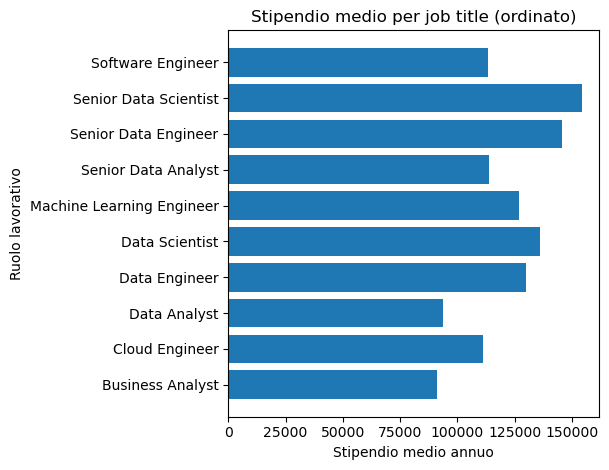

In [6]:
import matplotlib.pyplot as plt

mean_job_title_short = df.groupby("job_title_short")["salary_year_avg"].mean()

plt.figure()
plt.barh(mean_job_title_short.index, mean_job_title_short.values)

# Etichette e titolo
plt.xlabel("Stipendio medio annuo")
plt.ylabel("Ruolo lavorativo")
plt.title("Stipendio medio per job title (ordinato)")

plt.tight_layout()
plt.show()
